In [1]:
import os
import warnings

os.environ["GTIFF_SRS_SOURCE"] = "EPSG"

warnings.filterwarnings("ignore")

In [2]:
!pip install terratorch
!pip install gdown tensorboard
!pip install -U jupyter ipywidgets

In [3]:
import os
import sys
import torch
import gdown
import terratorch
import albumentations
import lightning.pytorch as pl
import matplotlib.pyplot as plt
from terratorch.datamodules import GenericNonGeoSegmentationDataModule
import optuna
import warnings

warnings.filterwarnings("ignore")

W0427 13:35:17.808000 29972 .venv\Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


In [4]:
import torch

print("===================================")
print("CUDA CHECK")
print("===================================")

print("PyTorch version:", torch.__version__)

print("CUDA available:", torch.cuda.is_available())

print("CUDA device count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("Current device:", torch.cuda.current_device())
    print("GPU name:", torch.cuda.get_device_name(0))

    print("CUDA version used by PyTorch:", torch.version.cuda)

    x = torch.rand(3, 3).cuda()
    print("\nTensor successfully moved to GPU:")
    print(x)
    print("Device:", x.device)

else:
    print("GPU NOT being used")

print("===================================")

CUDA CHECK
PyTorch version: 2.11.0+cu128
CUDA available: True
CUDA device count: 1
Current device: 0
GPU name: NVIDIA GeForce RTX 4060 Laptop GPU
CUDA version used by PyTorch: 12.8

Tensor successfully moved to GPU:
tensor([[0.9557, 0.5127, 0.9729],
        [0.8858, 0.0649, 0.9441],
        [0.7113, 0.7559, 0.8791]], device='cuda:0')
Device: cuda:0


In [5]:
from huggingface_hub import snapshot_download

DATASET_PATH = "./SmallMinesDS"

#snapshot_download(
#    repo_id="ellaampy/SmallMinesDS",
#    repo_type="dataset",
#    local_dir=DATASET_PATH,
#    local_dir_use_symlinks=False
#)

print("Dataset en:", DATASET_PATH)

Dataset en: ./SmallMinesDS


In [6]:
#import zipfile
#
#with zipfile.ZipFile("SmallMinesDS/SmallMinesDS.zip", 'r') as z:
#    z.extractall("SmallMinesDS")

In [6]:
!dir SmallMinesDS\SmallMinesDS

 Volume in drive C is Windows-SSD
 Volume Serial Number is 789D-9F40

 Directory of C:\Users\plieg\PycharmProjects\Minery\SmallMinesDS\SmallMinesDS

03/04/2026  20:08    <DIR>          .
03/04/2026  20:08    <DIR>          ..
03/04/2026  20:08    <DIR>          2016
03/04/2026  20:08    <DIR>          2022
               0 File(s)              0 bytes
               4 Dir(s)  76,760,743,936 bytes free


In [7]:
import rasterio
import os
import warnings
import logging

logging.getLogger().setLevel(logging.ERROR)

path = "SmallMinesDS/SmallMinesDS/2022/MASK/MASK_GH_1211_2022.tif"

with rasterio.open(path) as src:
    print("bands or mask:", src.count)
    print("shape of mask:", (src.count, src.height, src.width))

path = "SmallMinesDS/SmallMinesDS/2022/IMAGE/IMG_GH_1211_2022.tif"

with rasterio.open(path) as src:
    print("bands of image:", src.count)
    print("shape of image:", (src.count, src.height, src.width))


bands or mask: 1
shape of mask: (1, 128, 128)
bands of image: 13
shape of image: (13, 128, 128)


In [8]:
OUT_DIR = "./mine_example"

BATCH_SIZE = 8
SEED = 0
EPOCHS = 50

NUM_FRAMES = 2

BANDS = [
    "BLUE",
    "GREEN",
    "RED",
    "RED_EDGE_1",
    "RED_EDGE_2",
    "RED_EDGE_3",
    "NIR",
    "RED_EDGE_4",
    "SWIR_1",
    "SWIR_2",
    "VV",
    "VH",
    "DEM",
]

NUM_INPUT_CHANNELS = len(BANDS)

NUM_CLASSES = 2
IGNORE_INDEX = -1

PATCH_SIZE = 128

IMAGE_SHAPE_PER_TIMESTAMP = (13, 128, 128)
STACKED_IMAGE_SHAPE = (26, 128, 128)
TEMPORAL_IMAGE_SHAPE = (13, 2, 128, 128)

MASK_SHAPE = (1, 128, 128)
MASK_VALUES = [0, 1]

TARGET_YEAR = 2022
CONTEXT_YEAR = 2016

In [9]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

train_transforms = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),

    ToTensorV2(),
])

val_transforms = A.Compose([
    ToTensorV2(),
])

In [10]:
import os
import re
import torch
import numpy as np
import pandas as pd
import rasterio

from torch.utils.data import Dataset

class SmallMinesMultiTemporalDataset(Dataset):

    def __init__(
        self,
        root_dir,
        split="train",
        transform=None,
        check_alignment=False,
    ):
        self.root_dir = root_dir
        self.split = split
        self.transform = transform
        self.check_alignment = check_alignment

        csv_path = os.path.join(
            root_dir,
            "data_splits",
            "train_test_splits_2022.csv"
        )

        if not os.path.exists(csv_path):
            raise FileNotFoundError(
                f"No existe:\n{csv_path}"
            )

        self.df = pd.read_csv(csv_path)

        if split == "train":
            print("Splits disponibles:")
            print(self.df["split"].unique())

        self.df = self.df[
            self.df["split"] == split
        ].reset_index(drop=True)

        if len(self.df) == 0:
            raise ValueError(
                f"No hay muestras para split='{split}'"
            )

        self.img_2016_dir = os.path.join(
            root_dir,
            "SmallMinesDS",
            "2016",
            "IMAGE"
        )

        self.img_2022_dir = os.path.join(
            root_dir,
            "SmallMinesDS",
            "2022",
            "IMAGE"
        )

        self.mask_2022_dir = os.path.join(
            root_dir,
            "SmallMinesDS",
            "2022",
            "MASK"
        )

        if split == "train":
            print("\n==============================")
            print("SmallMinesMultiTemporalDataset")
            print("==============================")
            print(f"Split   : {split}")
            print(f"Samples : {len(self.df)}")
            print("==============================\n")

    def __len__(self):
        return len(self.df)

    def _extract_patch_id(self, filename):
        match = re.search(r"_(\d{4})_", filename)

        if match is None:
            raise ValueError(
                f"No se pudo extraer patch_id de:\n{filename}"
            )

        return match.group(1)

    def _build_paths(self, patch_id):
        img_2016 = os.path.join(
            self.img_2016_dir,
            f"IMG_GH_{patch_id}_2016.tif"
        )

        img_2022 = os.path.join(
            self.img_2022_dir,
            f"IMG_GH_{patch_id}_2022.tif"
        )

        mask_2022 = os.path.join(
            self.mask_2022_dir,
            f"MASK_GH_{patch_id}_2022.tif"
        )

        return img_2016, img_2022, mask_2022

    def _read_image(self, path):
        with rasterio.open(path) as src:
            image = src.read()

        return image.astype(np.float32)

    def _read_mask(self, path):
        with rasterio.open(path) as src:
            mask = src.read(1)

        mask = (mask > 0).astype(np.uint8)

        return mask

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        mask_name = row["patch_name"]
        patch_id = self._extract_patch_id(mask_name)

        img_2016_path, img_2022_path, mask_2022_path = self._build_paths(patch_id)

        img_2016 = self._read_image(img_2016_path)
        img_2022 = self._read_image(img_2022_path)
        mask_2022 = self._read_mask(mask_2022_path)

        image = np.stack([img_2016, img_2022], axis=1)

        if self.transform is not None:
            image_for_aug = image.reshape(
                13 * NUM_FRAMES,
                image.shape[2],
                image.shape[3]
            )

            transformed = self.transform(
                image=image_for_aug.transpose(1, 2, 0),
                mask=mask_2022
            )

            image = transformed["image"]
            mask_2022 = transformed["mask"]

            image = image.reshape(
                13,
                NUM_FRAMES,
                image.shape[1],
                image.shape[2]
            )

        if not isinstance(image, torch.Tensor):
            image = torch.from_numpy(image).float()

        if not isinstance(mask_2022, torch.Tensor):
            mask_2022 = torch.from_numpy(mask_2022)

        mask_2022 = mask_2022.long()

        return {
            "image": image,
            "mask": mask_2022,
            "filename": row["patch_name"],
        }

In [11]:
import pandas as pd

df = pd.read_csv(
    "SmallMinesDS/data_splits/train_test_splits_2022.csv"
)

print(df["split"].unique())

<ArrowStringArray>
['train', 'test']
Length: 2, dtype: str


In [12]:
from torch.utils.data import DataLoader
import os
import warnings

os.environ["GTIFF_SRS_SOURCE"] = "EPSG"

warnings.filterwarnings("ignore")

train_dataset = SmallMinesMultiTemporalDataset(
    root_dir=DATASET_PATH,
    split="train",
    transform=train_transforms,
    check_alignment=False
)

val_dataset = SmallMinesMultiTemporalDataset(
    root_dir=DATASET_PATH,
    split="test",
    transform=val_transforms,
    check_alignment=False
)

train_loader = DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    drop_last=False
)

print("\n==============================")
print("SINGLE SAMPLE CHECK")
print("==============================")

sample = train_dataset[0]

print("image shape:", sample["image"].shape)
print("mask shape :", sample["mask"].shape)
print("mask unique:", torch.unique(sample["mask"]))

print("==============================\n")

print("==============================")
print("LOADING FIRST BATCH...")
print("==============================")

for i, batch in enumerate(train_loader):
    if i == 4:
        break

print("==============================")
print("BATCH CHECK")
print("==============================")

print("batch image shape:", batch["image"].shape)
print("batch mask shape :", batch["mask"].shape)

print("==============================")

Splits disponibles:
<ArrowStringArray>
['train', 'test']
Length: 2, dtype: str

SmallMinesMultiTemporalDataset
Split   : train
Samples : 1491


SINGLE SAMPLE CHECK
image shape: torch.Size([13, 2, 128, 128])
mask shape : torch.Size([128, 128])
mask unique: tensor([0, 1])

LOADING FIRST BATCH...
BATCH CHECK
batch image shape: torch.Size([1, 13, 2, 128, 128])
batch mask shape : torch.Size([1, 128, 128])


In [13]:
import lightning.pytorch as pl
from torch.utils.data import DataLoader

class SmallMinesDataModule(pl.LightningDataModule):

    def __init__(
        self,
        root_dir,
        batch_size=BATCH_SIZE,
        num_workers=0,   # ← CAMBIAR
        train_transform=None,
        val_transform=None,
    ):
        super().__init__()

        self.root_dir = root_dir
        self.batch_size = batch_size
        self.num_workers = num_workers

        self.train_transform = train_transform
        self.val_transform = val_transform

    def prepare_data(self):
        pass

    def train_dataloader(self):
        return DataLoader(
            self.train_dataset,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=self.num_workers,

            pin_memory=True,              # ← CAMBIAR

            drop_last=False,
        )

    def val_dataloader(self):
        return DataLoader(
            self.val_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,

            pin_memory=True,              # ← CAMBIAR

            drop_last=False,
        )

    def test_dataloader(self):
        return DataLoader(
            self.test_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,

            pin_memory=True,              # ← CAMBIAR

            drop_last=False,
        )

    def predict_dataloader(self):
        predict_dataset = SmallMinesMultiTemporalDataset(
            root_dir=self.root_dir,
            split="test",
            transform=self.val_transform,
            check_alignment=False,
        )

        return DataLoader(
            predict_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=0,
            pin_memory=True,
            drop_last=False,
        )

    def setup(self, stage=None):

        if stage in ["fit", "validate", None]:
            self.train_dataset = SmallMinesMultiTemporalDataset(
                root_dir=self.root_dir,
                split="train",
                transform=self.train_transform,
                check_alignment=False,
            )

            self.val_dataset = SmallMinesMultiTemporalDataset(
                root_dir=self.root_dir,
                split="test",
                transform=self.val_transform,
                check_alignment=False,
            )

        if stage in ["test", "predict", None]:
            self.test_dataset = SmallMinesMultiTemporalDataset(
                root_dir=self.root_dir,
                split="test",
                transform=self.val_transform,
                check_alignment=False,
            )

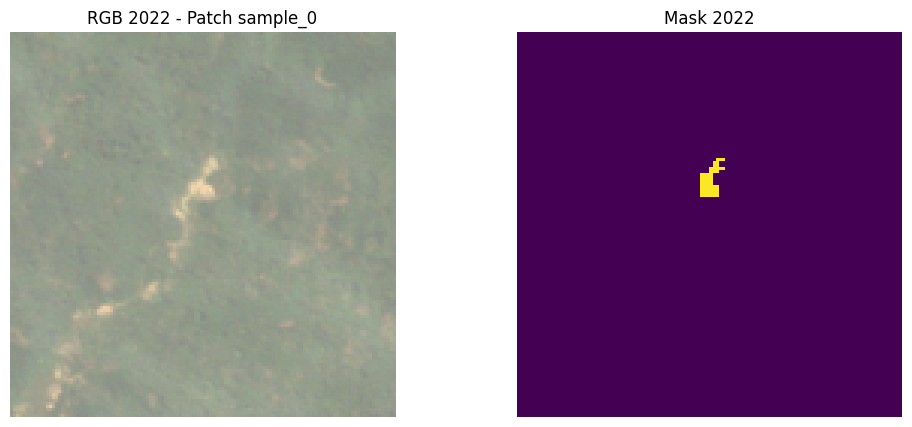

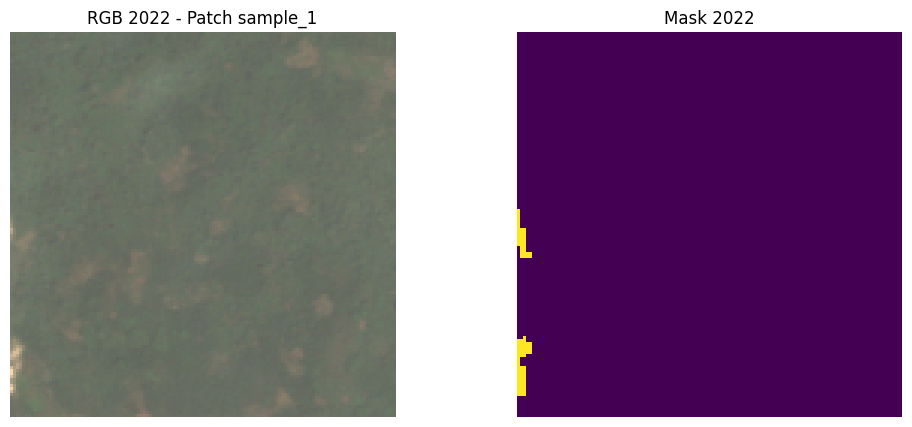

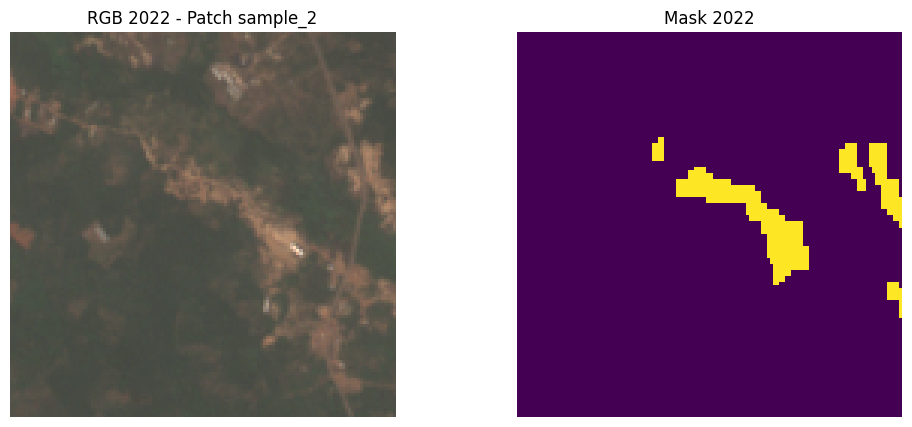

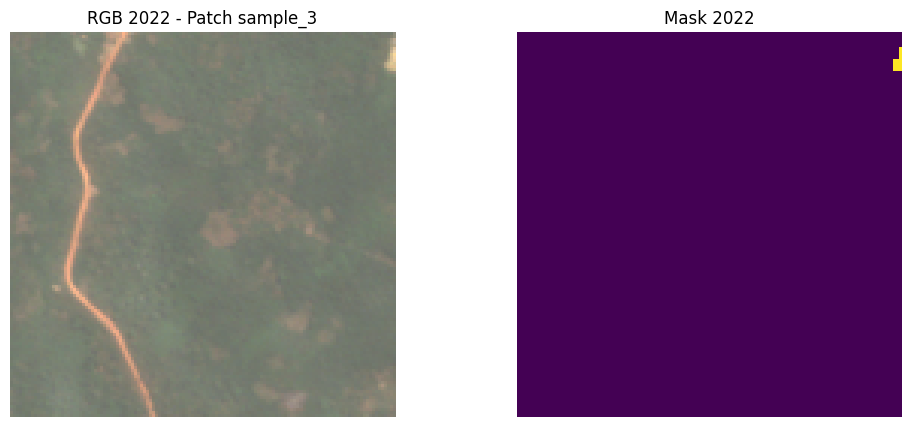

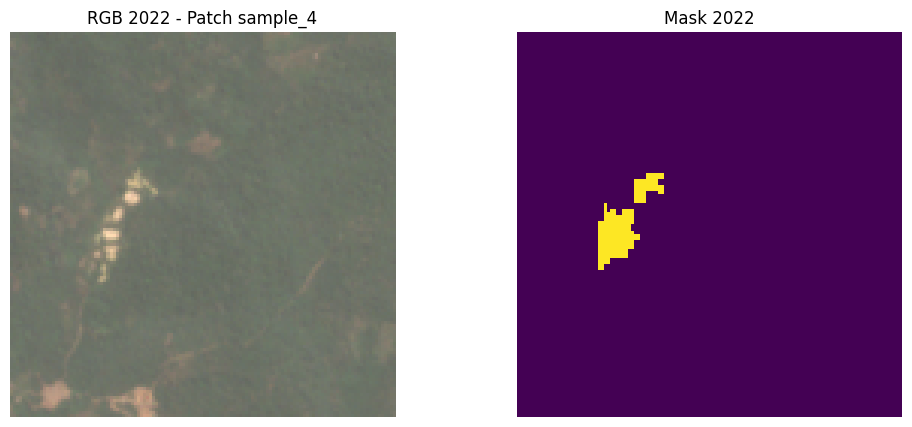

In [14]:
import matplotlib.pyplot as plt
import numpy as np


for i in range(5):
    sample = train_dataset[i]

    image = sample["image"]
    mask = sample["mask"]

    patch_id = f"sample_{i}"

    red_2022 = image[2, 1]
    green_2022 = image[1, 1]
    blue_2022 = image[0, 1]

    rgb_2022 = np.stack(
        [red_2022, green_2022, blue_2022],
        axis=-1
    )

    rgb_2022 = rgb_2022.astype(np.float32)

    if rgb_2022.max() > 0:
        rgb_2022 = rgb_2022 / rgb_2022.max()

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(rgb_2022)
    plt.title(f"RGB 2022 - Patch {patch_id}")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(mask)
    plt.title("Mask 2022")
    plt.axis("off")

    plt.show()

In [16]:
print("Validation split size")
print("---------------------")

print("Number of validation samples:", len(val_dataset))

print("---------------------")
print("Validation split used:", "test")
print("(porque tu CSV tiene train + test, no train + val)")
print("---------------------")

Validation split size
---------------------
Number of validation samples: 644
---------------------
Validation split used: test
(porque tu CSV tiene train + test, no train + val)
---------------------


In [15]:
from terratorch.registry import MODEL_FACTORY_REGISTRY

factory = MODEL_FACTORY_REGISTRY.build("EncoderDecoderFactory")

print(
    factory.build_model(
        task="segmentation",
        backbone="prithvi_eo_v2_600_tl",
        backbone_kwargs=dict(
            pretrained=True,
            bands=BANDS,
            num_frames=NUM_FRAMES,
            coords_encoding=["time", "location"],
        ),
        decoder="IdentityDecoder",
        num_classes=2,
    )
)

2026-04-27 13:35:49,174 - WARNING - Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.


PixelWiseModel(
  (encoder): PrithviViT(
    (patch_embed): PatchEmbed(
      (proj): Conv3d(13, 1280, kernel_size=(1, 14, 14), stride=(1, 14, 14))
      (norm): Identity()
    )
    (temporal_embed_enc): TemporalEncoder()
    (location_embed_enc): LocationEncoder()
    (blocks): ModuleList(
      (0-31): 32 x Block(
        (norm1): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=1280, out_features=3840, bias=True)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inplace=False)
          (norm): Identity()
          (proj): Linear(in_features=1280, out_features=1280, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): Identity()
        (drop_path1): Identity()
        (norm2): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=1280, out_features=5120, bias=True)
       

In [ ]:
import os
import optuna
import torch
import lightning.pytorch as pl

from lightning.pytorch.callbacks import ModelCheckpoint
from terratorch.tasks import SemanticSegmentationTask
from optuna.integration import PyTorchLightningPruningCallback
from lightning.pytorch.loggers import TensorBoardLogger


pl.seed_everything(SEED)


def objective(trial):

    lr = trial.suggest_float(
        "lr",
        5e-5,
        3e-4,
        log=True
    )

    weight_decay = trial.suggest_float(
        "weight_decay",
        1e-3,
        5e-2,
        log=True
    )

    head_dropout = trial.suggest_float(
        "head_dropout",
        0.0,
        0.3
    )

    freeze_backbone = True

    mine_weight = trial.suggest_float(
        "mine_weight",
        0.7,
        0.98
    )

    loss_name = trial.suggest_categorical(
        "loss",
        ["focal", "dice"]
    )

    class_weights = torch.tensor(
        [1 - mine_weight, mine_weight],
        dtype=torch.float32
    )

    data_module = SmallMinesDataModule(
        root_dir=DATASET_PATH,
        batch_size=BATCH_SIZE,
        num_workers=0,
        train_transform=train_transforms,
        val_transform=val_transforms,
    )

    backbone_args = dict(
        backbone_pretrained=True,
        backbone="prithvi_eo_v2_600_tl",
        backbone_coords_encoding=[
            "time",
            "location",
        ],
        backbone_bands=BANDS,
        backbone_num_frames=NUM_FRAMES,
    )

    necks = [
        {
            "name": "SelectIndices",
            "indices": [7,15,23,31]
        },
        {
            "name": "ReshapeTokensToImage",
            "effective_time_dim": NUM_FRAMES,
        }
    ]

    decoder_args = dict(
        decoder="UperNetDecoder",
        decoder_channels=512,
        decoder_scale_modules=True,
    )

    model_args = dict(
        **backbone_args,
        **decoder_args,
        num_classes=2,
        head_dropout=head_dropout,
        necks=necks,
        rescale=True,
    )

    model = SemanticSegmentationTask(
        model_factory="EncoderDecoderFactory",
        model_args=model_args,
        plot_on_val=False,
        class_weights=class_weights,
        loss=loss_name,
        lr=lr,
        optimizer="AdamW",
        optimizer_hparams=dict(
            weight_decay=weight_decay
        ),
        ignore_index=-1,
        freeze_backbone=freeze_backbone,
        freeze_decoder=False,
    )

    checkpoint_callback = ModelCheckpoint(
        monitor="val/mIoU",
        mode="max",
        dirpath=os.path.join(
            OUT_DIR,
            "optuna_checkpoints"
        ),
        filename="best-{epoch:02d}",
        save_top_k=1,
        save_last=False,
    )

    trainer = pl.Trainer(
        accelerator="auto",
        strategy="auto",
        devices=1,
        num_nodes=1,
        precision="bf16-mixed",
        max_epochs=15,
        logger = TensorBoardLogger(
            save_dir=OUT_DIR,
            name="optuna_runs",
            version=f"trial_{trial.number}"
        ),
        callbacks=[
            checkpoint_callback,
            PyTorchLightningPruningCallback(
                trial,
                monitor="val/mIoU"
            )
        ],
        log_every_n_steps=10,
        check_val_every_n_epoch=1,
        num_sanity_val_steps=0,
        limit_val_batches=1.0,
        enable_progress_bar=False,
        enable_checkpointing=True,
    )

    trainer.fit(
        model=model,
        datamodule=data_module,
    )

    score = trainer.callback_metrics["val/mIoU"].item()

    return score


study = optuna.create_study(
    direction="maximize",
    storage="sqlite:///optuna_mines.db",
    study_name="smallmines_hpo",
    load_if_exists=True
)
study.optimize(
    objective,
    n_trials=20
)

print("===================================")
print("BEST TRIAL")
print("===================================")

print(study.best_trial.params)

print("===================================")
print("BEST val/mIoU")
print("===================================")

print(study.best_value)

Seed set to 0
[I 2026-04-27 09:29:51,407] A new study created in RDB with name: smallmines_hpo
Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
`Trainer(limit_val_batches=1.0)` was configured so 100% of the batches will be used..
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Splits disponibles:
<ArrowStringArray>
['train', 'test']
Length: 2, dtype: str

SmallMinesMultiTemporalDataset
Split   : train
Samples : 1491



┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model         │ PixelWiseModel   │  707 M │ train │     0 │
│ 1 │ criterion     │ FocalLoss        │      0 │ train │     0 │
│ 2 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 3 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
│ 4 │ test_metrics  │ ModuleList       │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 74.8 M                                                                                           
Non-trainable params: 632 M                                                                                        
Total params: 707 M                                                                                                
Total estimated model params size (MB): 2.8 K                                                                      
Modules in train mode: 828                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

`Trainer.fit` stopped: `max_epochs=15` reached.
[I 2026-04-27 11:17:14,527] Trial 0 finished with value: 0.8505505323410034 and parameters: {'lr': 0.00010213277342770887, 'weight_decay': 0.0018775409496516282, 'head_dropout': 0.040799188852986744, 'mine_weight': 0.7678827350026017, 'loss': 'focal'}. Best is trial 0 with value: 0.8505505323410034.
Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
`Trainer(limit_val_batches=1.0)` was configured so 100% of the batches will be used..
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

Trainable params: 74.8 M                                                                                           
Non-trainable params: 632 M                                                                                        
Total params: 707 M                                                                                                
Total estimated model params size (MB): 2.8 K                                                                      
Modules in train mode: 828                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

`Trainer.fit` stopped: `max_epochs=15` reached.
[I 2026-04-27 13:13:06,374] Trial 1 finished with value: 0.8423758745193481 and parameters: {'lr': 0.00017774334613625725, 'weight_decay': 0.008593796179892766, 'head_dropout': 0.11934971309091512, 'mine_weight': 0.9581659578370407, 'loss': 'focal'}. Best is trial 0 with value: 0.8505505323410034.
Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
`Trainer(limit_val_batches=1.0)` was configured so 100% of the batches will be used..
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Splits disponibles:
<ArrowStringArray>
['train', 'test']
Length: 2, dtype: str

SmallMinesMultiTemporalDataset
Split   : train
Samples : 1491



┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model         │ PixelWiseModel   │  707 M │ train │     0 │
│ 1 │ criterion     │ DiceLoss         │      0 │ train │     0 │
│ 2 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 3 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
│ 4 │ test_metrics  │ ModuleList       │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 74.8 M                                                                                           
Non-trainable params: 632 M                                                                                        
Total params: 707 M                                                                                                
Total estimated model params size (MB): 2.8 K                                                                      
Modules in train mode: 828                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

In [73]:
import time

print("Testing dataset speed...")

start = time.time()

for i in range(20):
    sample = train_dataset[i]

end = time.time()

print("===================================")
print("20 samples time:", end - start, "seconds")
print("Average per sample:", (end - start) / 20, "seconds")
print("===================================")

Testing dataset speed...
20 samples time: 2.964270830154419 seconds
Average per sample: 0.14821354150772095 seconds


In [19]:
import optuna

study = optuna.load_study(
    study_name="smallmines_hpo",
    storage="sqlite:///optuna_mines.db"
)

print("===================================")
print("BEST TRIAL RECOVERED")
print("===================================")
print(study.best_trial.params)

print("===================================")
print("BEST VALUE")
print("===================================")
print(study.best_value)

BEST TRIAL RECOVERED
{'lr': 0.00010213277342770887, 'weight_decay': 0.0018775409496516282, 'head_dropout': 0.040799188852986744, 'mine_weight': 0.7678827350026017, 'loss': 'focal'}
BEST VALUE
0.8505505323410034


In [21]:
import optuna
import torch
import lightning.pytorch as pl

from terratorch.tasks import SemanticSegmentationTask

# =========================================================
# RECOVER OPTUNA STUDY
# =========================================================

study = optuna.load_study(
    study_name="smallmines_hpo",
    storage="sqlite:///optuna_mines.db"
)

best_params = study.best_trial.params

print("===================================")
print("BEST PARAMS")
print("===================================")
print(best_params)

# =========================================================
# REBUILD DATAMODULE
# =========================================================

data_module = SmallMinesDataModule(
    root_dir=DATASET_PATH,
    batch_size=BATCH_SIZE,
    num_workers=0,
    train_transform=train_transforms,
    val_transform=val_transforms,
)

# =========================================================
# REBUILD MODEL
# =========================================================

class_weights = torch.tensor(
    [
        1 - best_params["mine_weight"],
        best_params["mine_weight"]
    ],
    dtype=torch.float32
)

backbone_args = dict(
    backbone_pretrained=True,
    backbone="prithvi_eo_v2_600_tl",
    backbone_coords_encoding=[
        "time",
        "location",
    ],
    backbone_bands=BANDS,
    backbone_num_frames=NUM_FRAMES,
)

necks = [
    {
        "name": "SelectIndices",
        "indices": [7, 15, 23, 31]
    },
    {
        "name": "ReshapeTokensToImage",
        "effective_time_dim": NUM_FRAMES,
    }
]

decoder_args = dict(
    decoder="UperNetDecoder",
    decoder_channels=512,
    decoder_scale_modules=True,
)

model_args = dict(
    **backbone_args,
    **decoder_args,
    num_classes=2,
    head_dropout=best_params["head_dropout"],
    necks=necks,
    rescale=True,
)

model = SemanticSegmentationTask(
    model_factory="EncoderDecoderFactory",
    model_args=model_args,
    plot_on_val=False,
    class_weights=class_weights,
    loss=best_params["loss"],
    lr=best_params["lr"],
    optimizer="AdamW",
    optimizer_hparams=dict(
        weight_decay=best_params["weight_decay"]
    ),
    ignore_index=-1,
    freeze_backbone=True,
    freeze_decoder=False,
)

# =========================================================
# REBUILD TRAINER
# =========================================================

trainer = pl.Trainer(
    accelerator="auto",
    devices=1,
    precision="bf16-mixed",
    logger=False,
)

print("===================================")
print("MODEL + DATAMODULE + TRAINER READY")
print("===================================")

BEST PARAMS
{'lr': 0.00010213277342770887, 'weight_decay': 0.0018775409496516282, 'head_dropout': 0.040799188852986744, 'mine_weight': 0.7678827350026017, 'loss': 'focal'}


Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


MODEL + DATAMODULE + TRAINER READY


In [66]:
# =========================================================
# TEST / EVALUATION
# =========================================================

# usar el mejor checkpoint guardado durante training

ckpt_path = checkpoint_callback.best_model_path

print("===================================")
print("BEST CHECKPOINT")
print("===================================")
print(ckpt_path)
print("===================================")

if ckpt_path == "":
    raise ValueError(
        "No se encontró best_model_path.\n"
        "Revisa si trainer.fit() terminó correctamente."
    )


# =========================================================
# TEST RESULTS
# =========================================================

# IMPORTANTE:
#
# En tu caso:
#
# train -> entrenamiento
# test  -> validación / evaluación
#
# porque el CSV solo tiene:
#
# train + test
#
# no:
#
# train + val + test

print("Running evaluation on test split...")

test_results = trainer.test(
    model=model,
    datamodule=data_module,
    ckpt_path=ckpt_path,
)

print("===================================")
print("TEST RESULTS")
print("===================================")

for result in test_results:
    print(result)

print("===================================")

Restoring states from the checkpoint path at C:\Users\plieg\PycharmProjects\Minery\mine_example\smallmines_prithvi_temporal\checkpoints\best-checkpoint-epoch=01-val_loss=0.0000.ckpt


BEST CHECKPOINT
C:\Users\plieg\PycharmProjects\Minery\mine_example\smallmines_prithvi_temporal\checkpoints\best-checkpoint-epoch=01-val_loss=0.0000.ckpt
Running evaluation on test split...
Splits disponibles:
<ArrowStringArray>
['train', 'test']
Length: 2, dtype: str

SmallMinesMultiTemporalDataset
Split   : test
Samples : 644



LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at C:\Users\plieg\PycharmProjects\Minery\mine_example\smallmines_prithvi_temporal\checkpoints\best-checkpoint-epoch=01-val_loss=0.0000.ckpt


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test/Accuracy       │    0.8937543034553528     │
│    test/Boundary_mIoU     │     0.359414666891098     │
│   test/Class_Accuracy_0   │     0.980435311794281     │
│   test/Class_Accuracy_1   │    0.8070732951164246     │
│       test/F1_Score       │    0.8871585130691528     │
│        test/IoU_0         │    0.9646151065826416     │
│        test/IoU_1         │     0.656079113483429     │
│    test/Pixel_Accuracy    │    0.9668524861335754     │
│         test/loss         │    0.08311019837856293    │
│         test/mIoU         │    0.8103470802307129     │
│      test/mIoU_Micro      │    0.9358320832252502     │
└───────────────────────────┴───────────────────────────┘

TEST RESULTS
{'test/loss': 0.08311019837856293, 'test/Accuracy': 0.8937543034553528, 'test/Boundary_mIoU': 0.359414666891098, 'test/Class_Accuracy_0': 0.980435311794281, 'test/Class_Accuracy_1': 0.8070732951164246, 'test/F1_Score': 0.8871585130691528, 'test/IoU_0': 0.9646151065826416, 'test/IoU_1': 0.656079113483429, 'test/Pixel_Accuracy': 0.9668524861335754, 'test/mIoU': 0.8103470802307129, 'test/mIoU_Micro': 0.9358320832252502}


In [22]:
preds = trainer.predict(
    model=model,
    datamodule=data_module,
    ckpt_path=ckpt_path,
)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
Restoring states from the checkpoint path at ./mine_example\optuna_checkpoints\best-epoch=13-v1.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at ./mine_example\optuna_checkpoints\best-epoch=13-v1.ckpt


Output()

In [23]:
print("===================================")
print("TYPE OF preds")
print("===================================")
print(type(preds))
print()

print("===================================")
print("NUMBER OF BATCHES")
print("===================================")
print(len(preds))
print()

print("===================================")
print("FIRST BATCH TYPE")
print("===================================")
print(type(preds[0]))
print()

print("===================================")
print("FIRST BATCH CONTENT")
print("===================================")
print(preds[0])

TYPE OF preds
<class 'list'>

NUMBER OF BATCHES
81

FIRST BATCH TYPE
<class 'tuple'>

FIRST BATCH CONTENT
((tensor([[[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        ...,

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0

SEARCHING SAMPLES WITH REAL MINING


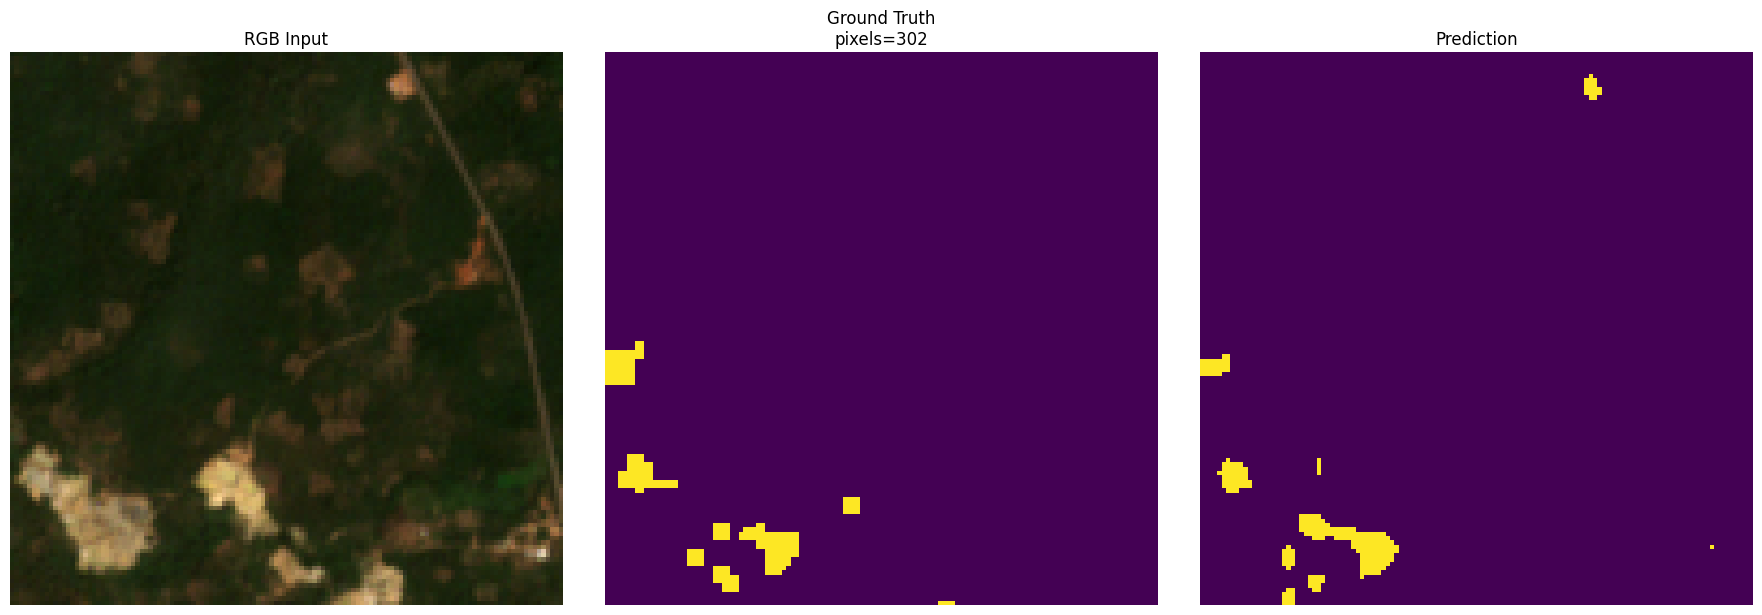

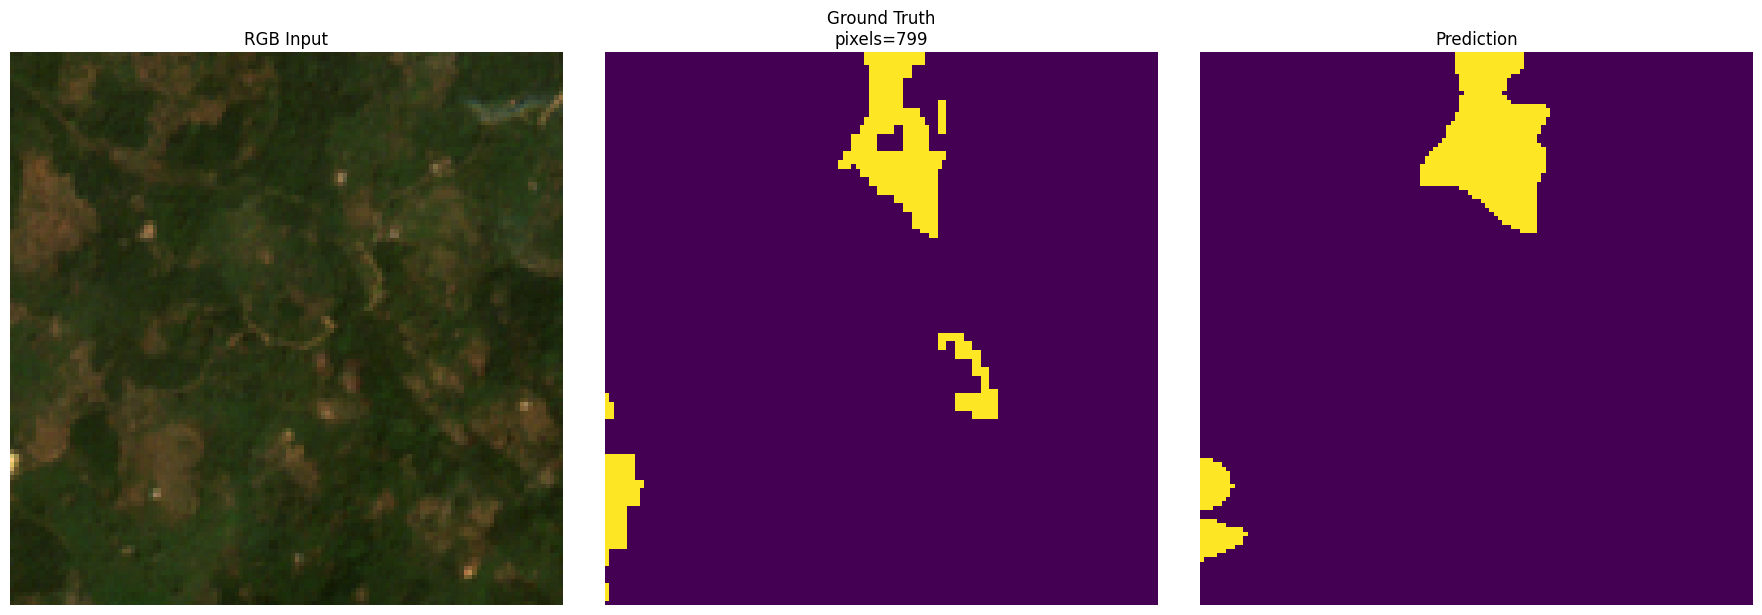

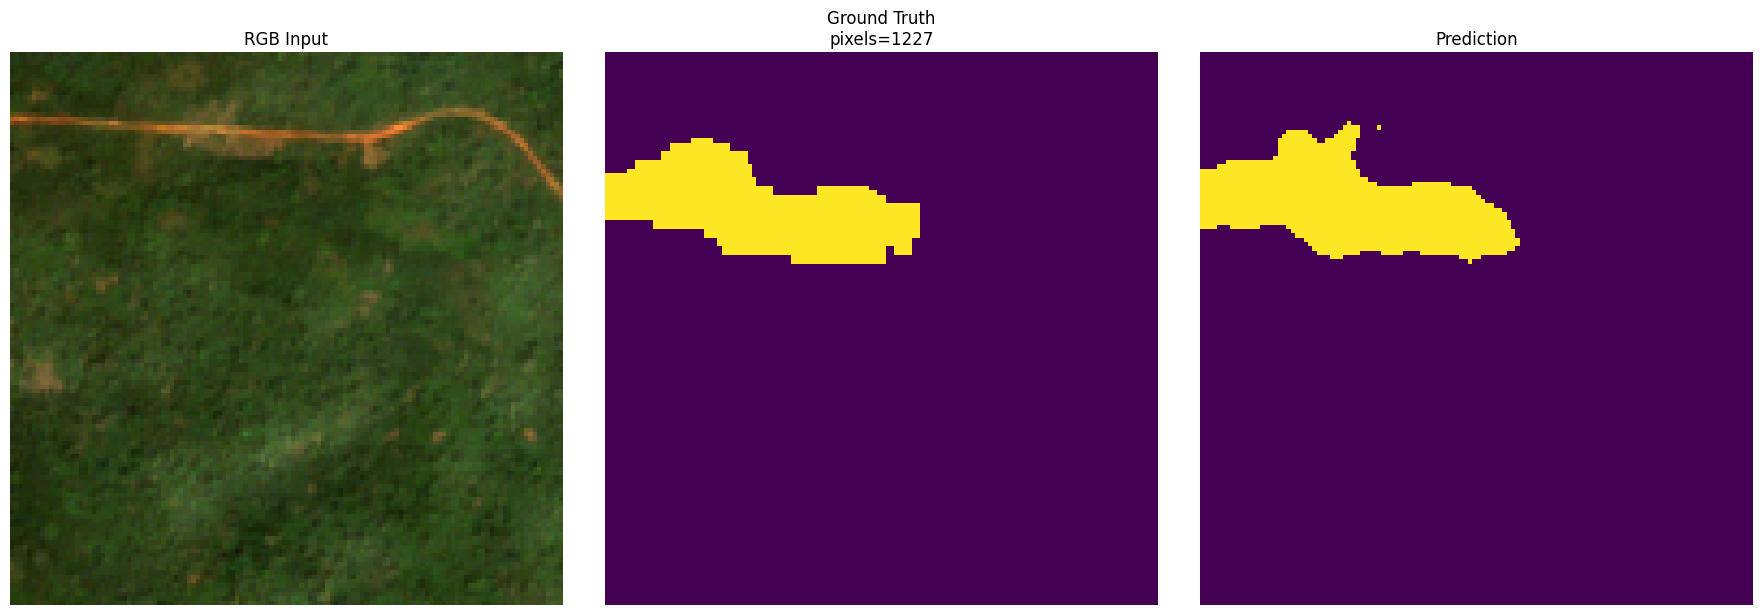

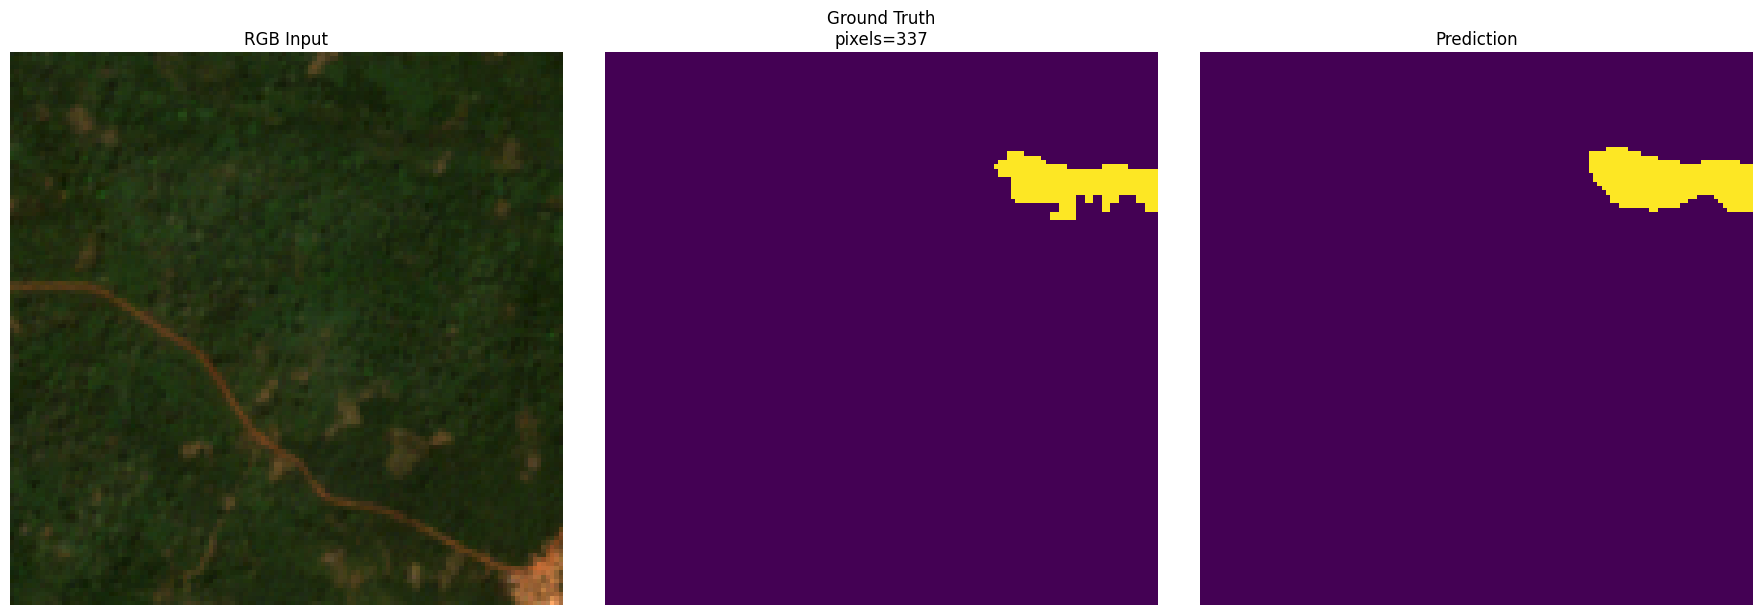

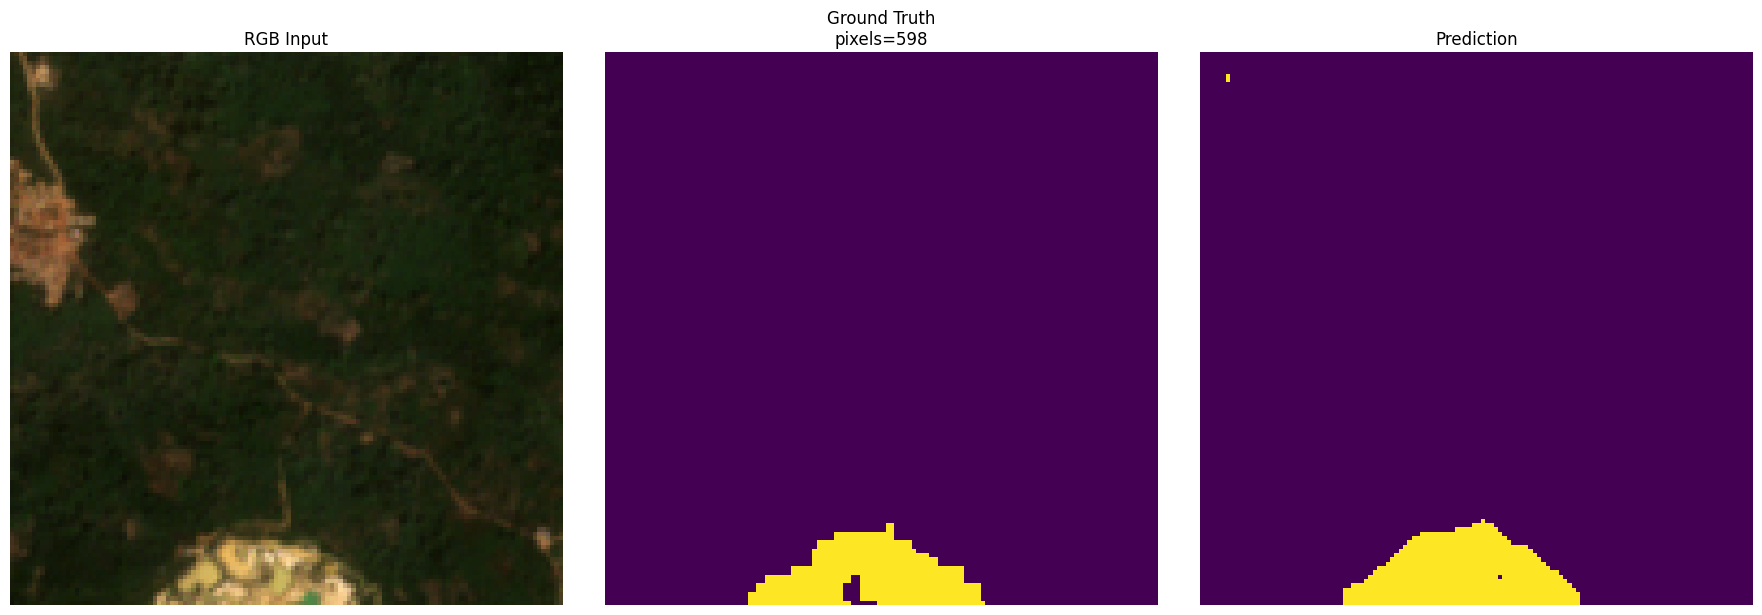

FOUND 5 GOOD SAMPLES


In [26]:
import matplotlib.pyplot as plt
import torch
import numpy as np

print("===================================")
print("SEARCHING SAMPLES WITH REAL MINING")
print("===================================")

data_module.setup(stage="test")
test_loader = data_module.test_dataloader()

model.eval()

found = 0
max_samples = 5  # número de ejemplos buenos a mostrar

for batch in test_loader:

    images = batch["image"]
    masks = batch["mask"]

    with torch.no_grad():
        logits = model(images.to(model.device))
        preds = torch.argmax(
            logits.output,
            dim=1
        ).cpu()

    batch_size = images.shape[0]

    for i in range(batch_size):

        gt = masks[i].squeeze().cpu().numpy()

        # contar píxeles positivos
        positive_pixels = (gt == 1).sum()

        # ignorar muestras casi vacías
        if positive_pixels < 300:
            continue

        pred = preds[i].numpy()

        # RGB usando primer timestamp
        rgb = images[i, [2, 1, 0], 0].cpu()
        rgb = rgb.permute(1, 2, 0).numpy()
        rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)

        fig, axes = plt.subplots(1, 3, figsize=(18, 6))

        axes[0].imshow(rgb)
        axes[0].set_title("RGB Input")
        axes[0].axis("off")

        axes[1].imshow(gt)
        axes[1].set_title(
            f"Ground Truth\npixels={positive_pixels}"
        )
        axes[1].axis("off")

        axes[2].imshow(pred)
        axes[2].set_title("Prediction")
        axes[2].axis("off")

        plt.tight_layout()
        plt.show()

        found += 1

        if found >= max_samples:
            break

    if found >= max_samples:
        break

print("===================================")
print(f"FOUND {found} GOOD SAMPLES")
print("===================================")

MULTIPLE BATCH VISUALIZATION
Splits disponibles:
<ArrowStringArray>
['train', 'test']
Length: 2, dtype: str

SmallMinesMultiTemporalDataset
Split   : test
Samples : 644


Showing batch 0


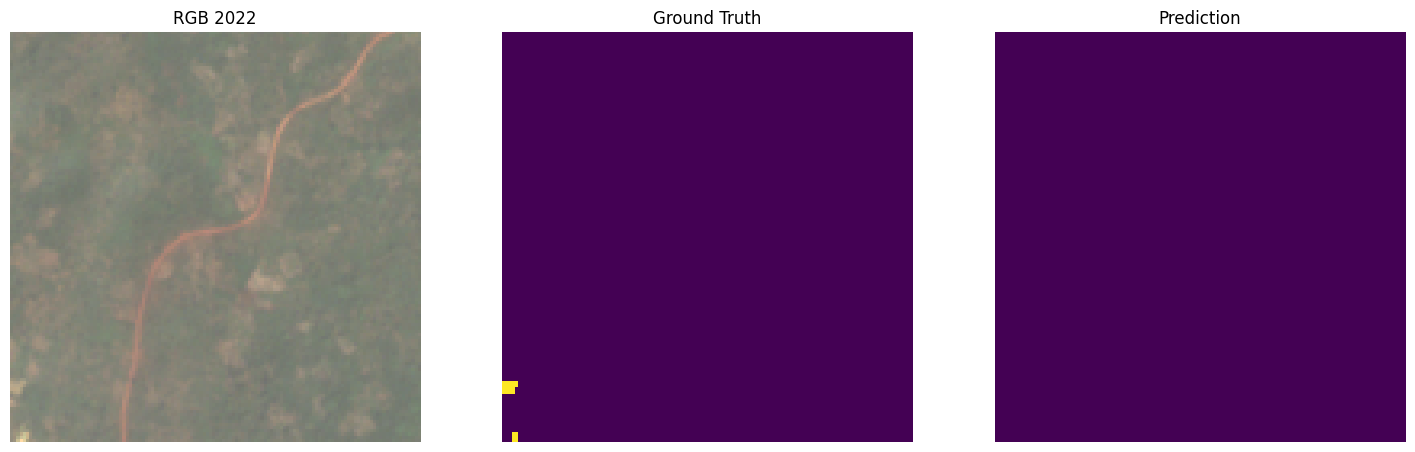

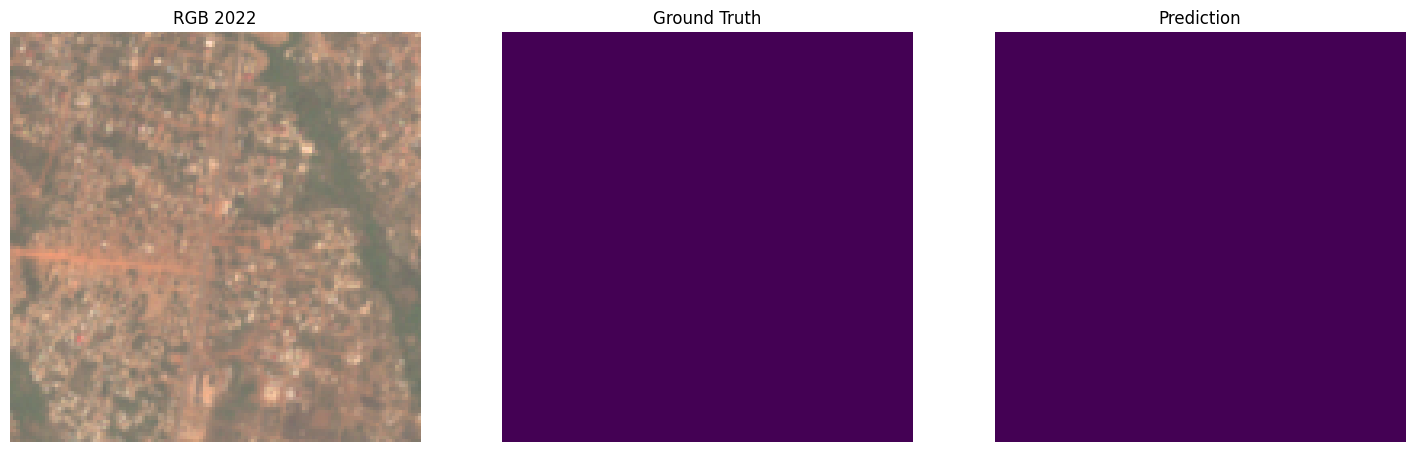

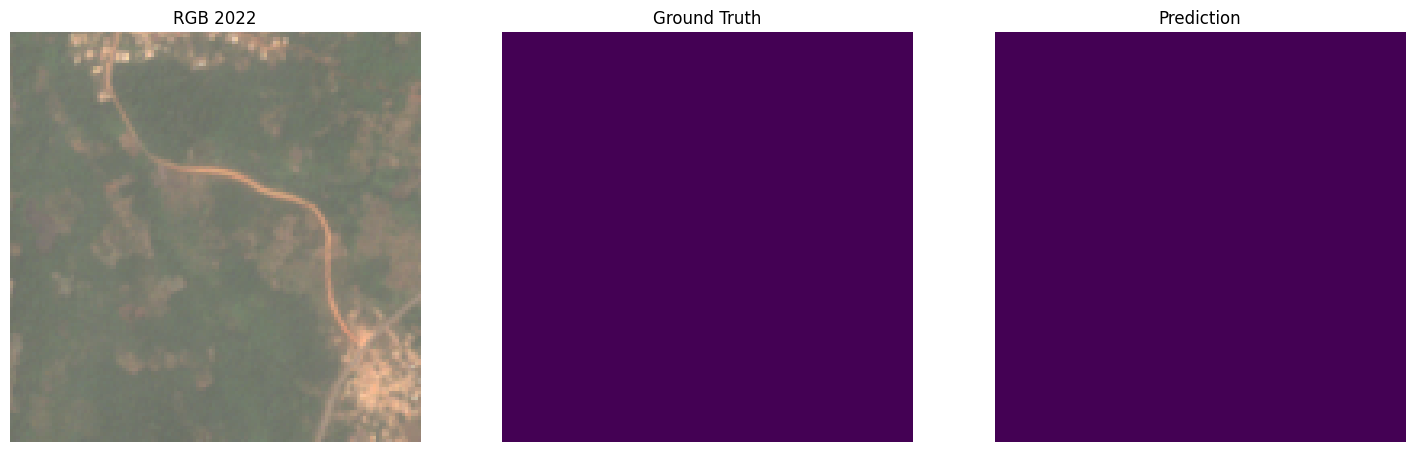

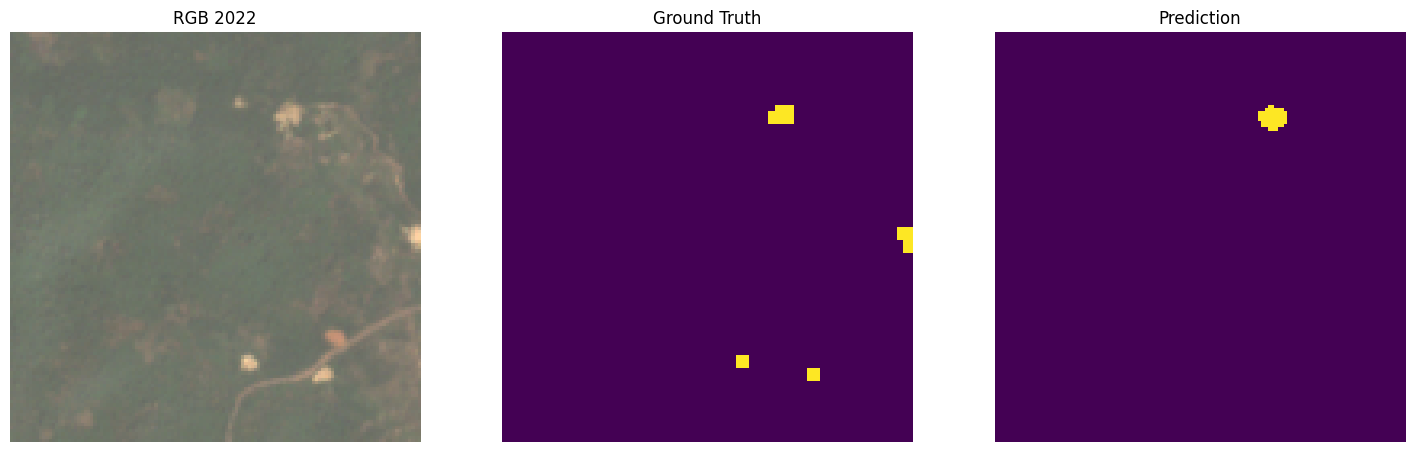


Showing batch 1


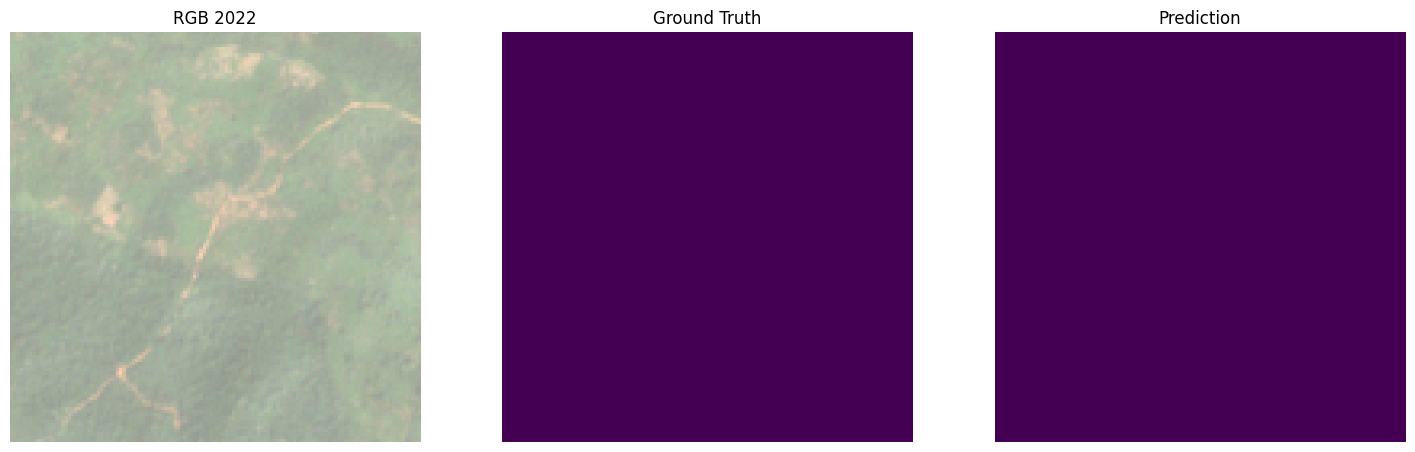

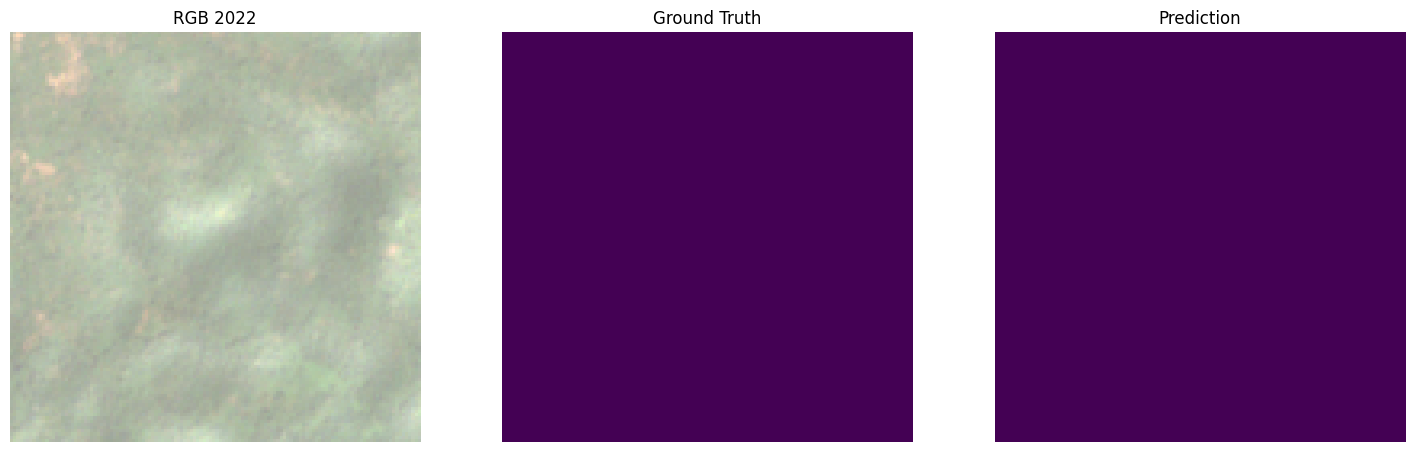

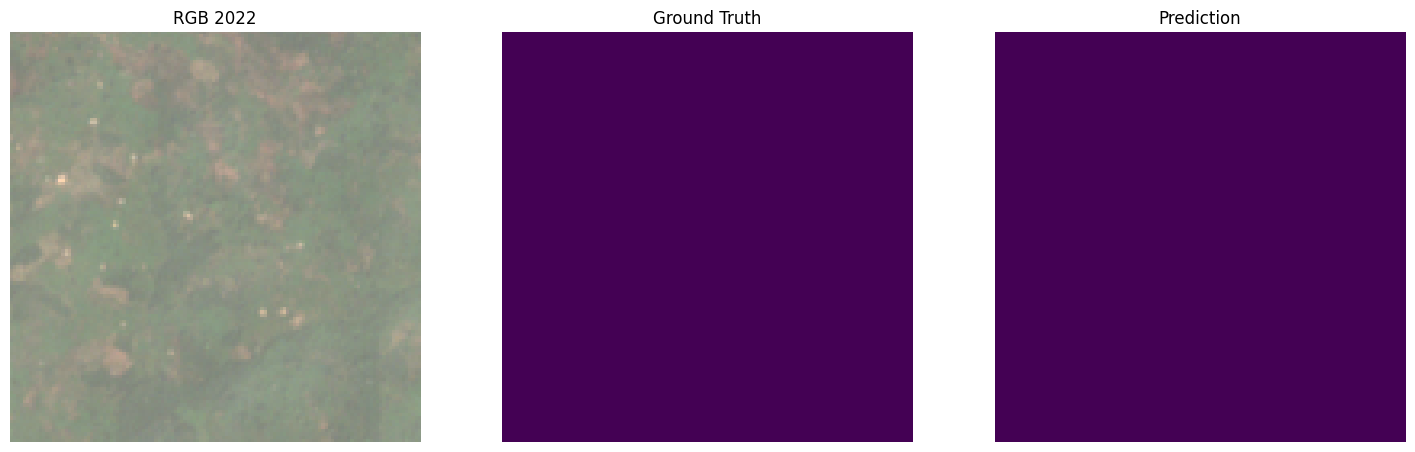

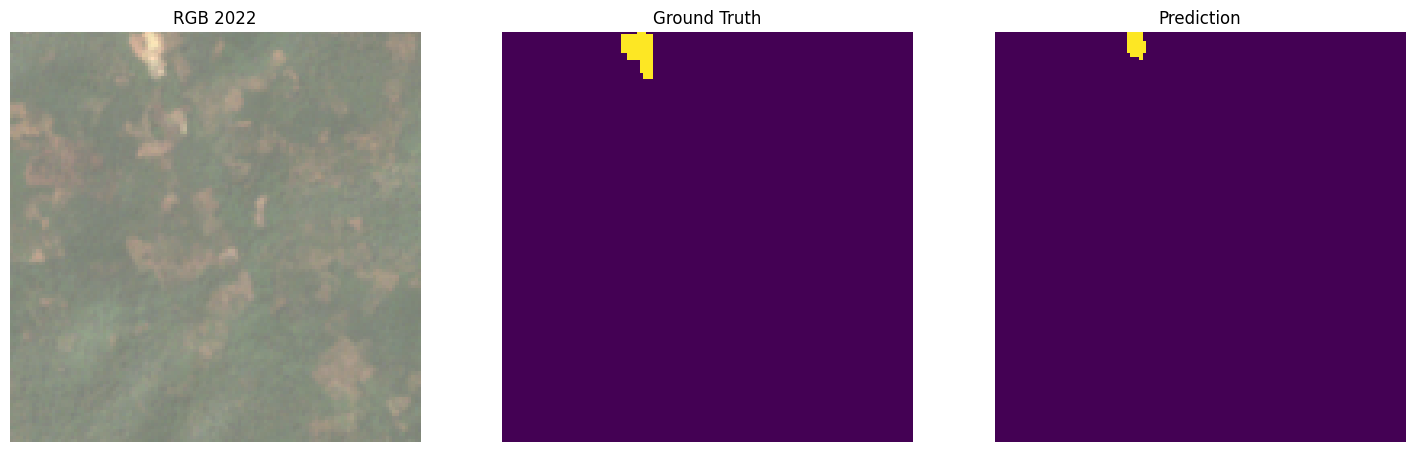


Showing batch 2


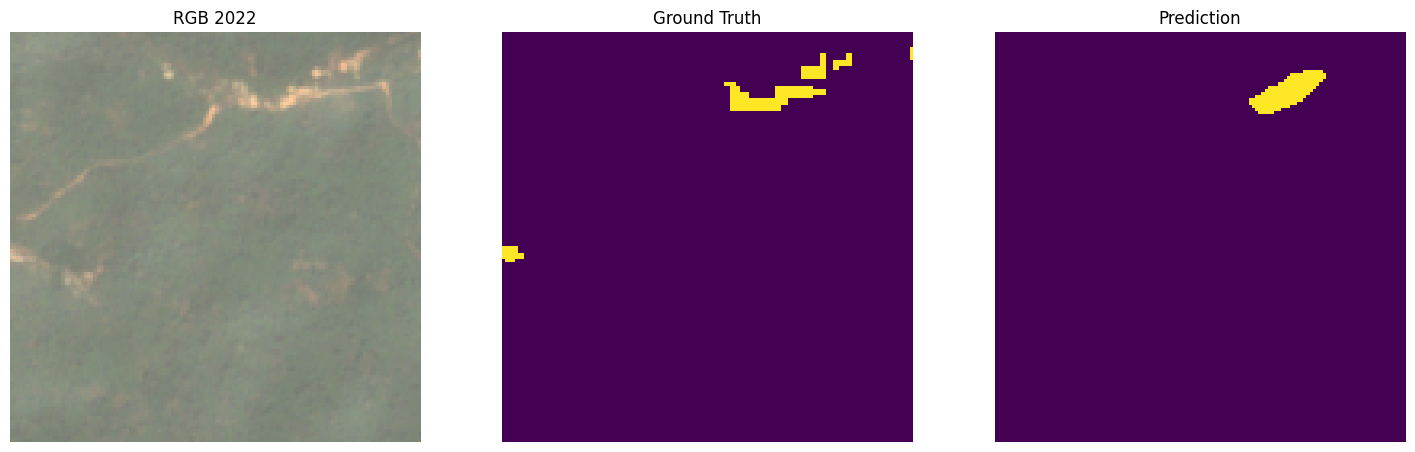

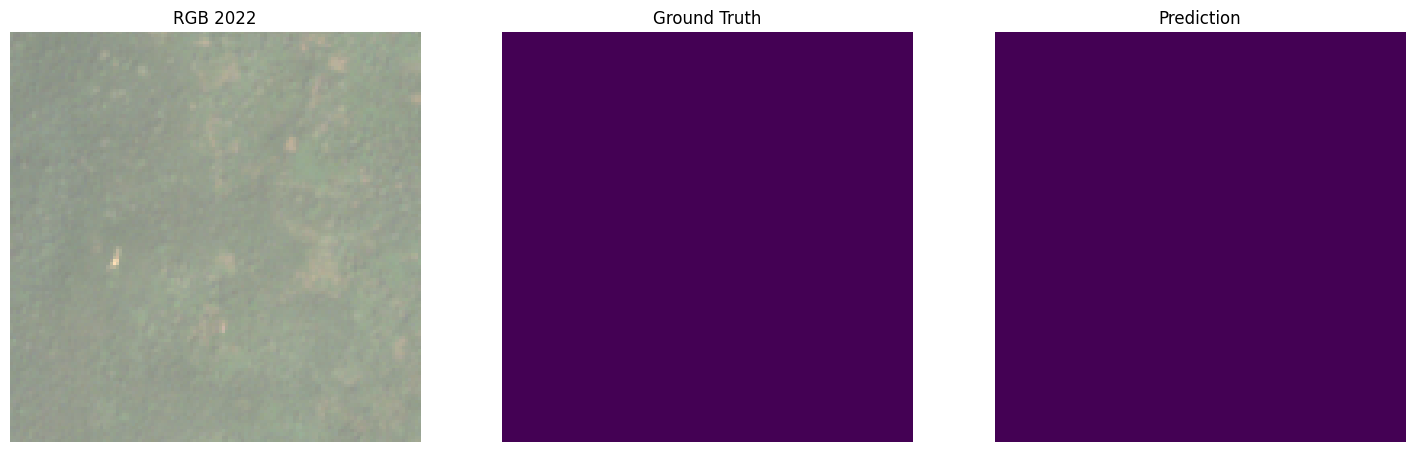

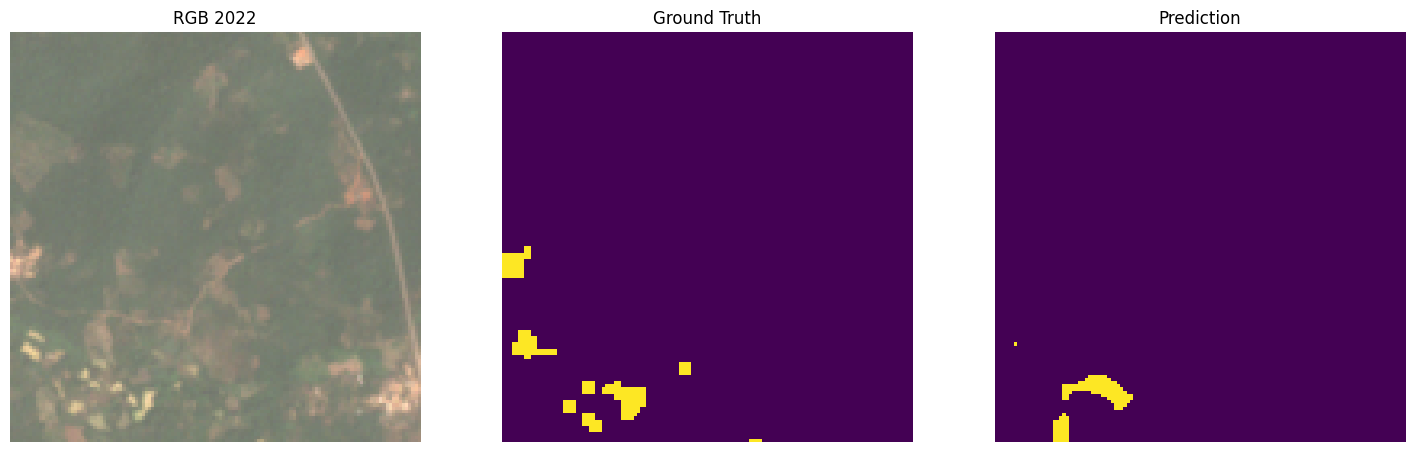

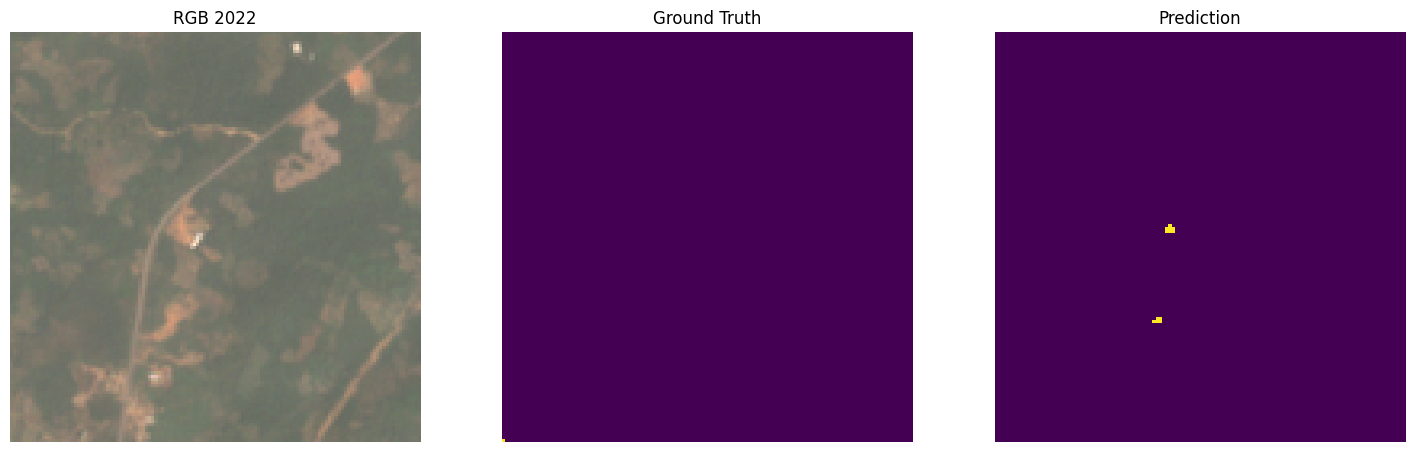


Showing batch 3


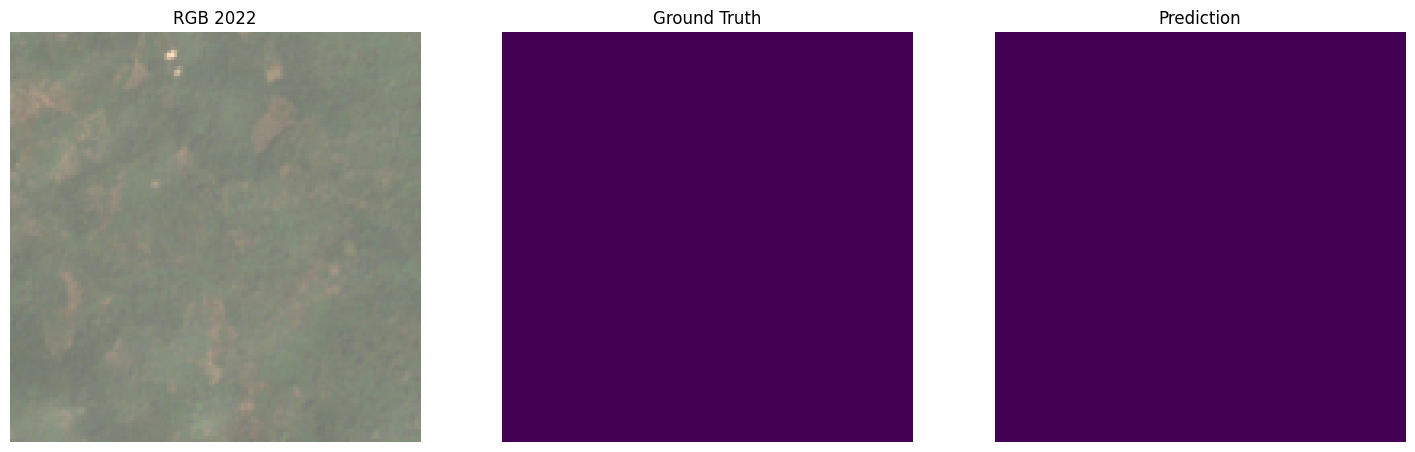

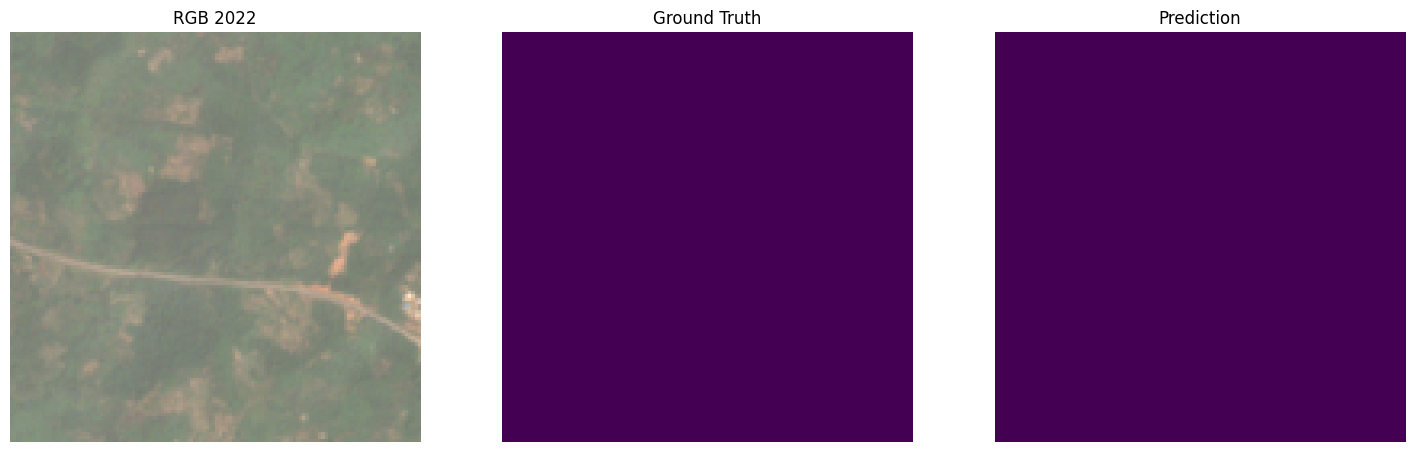

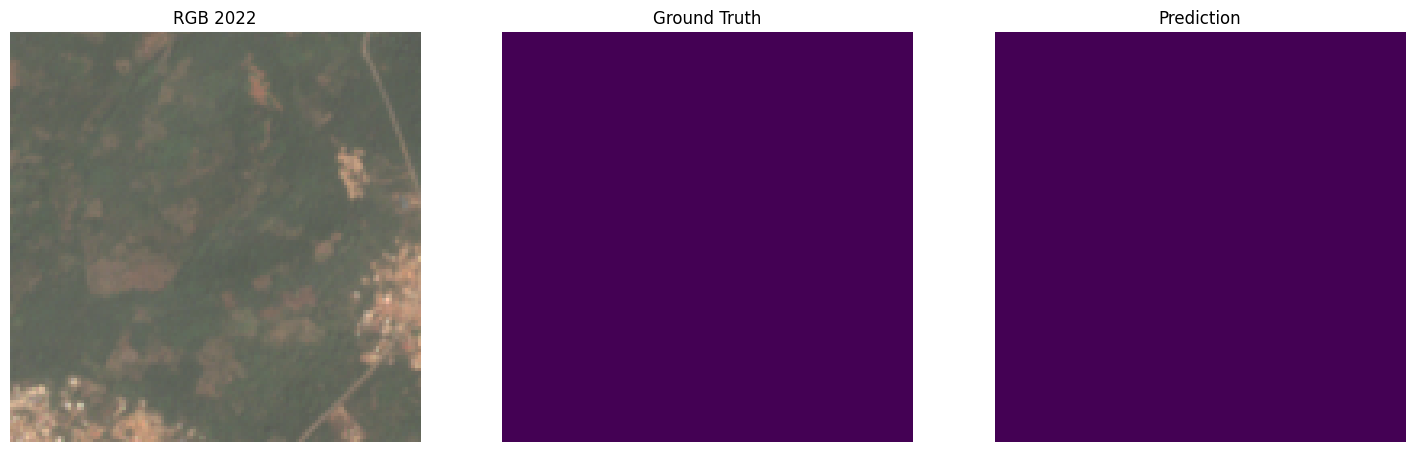

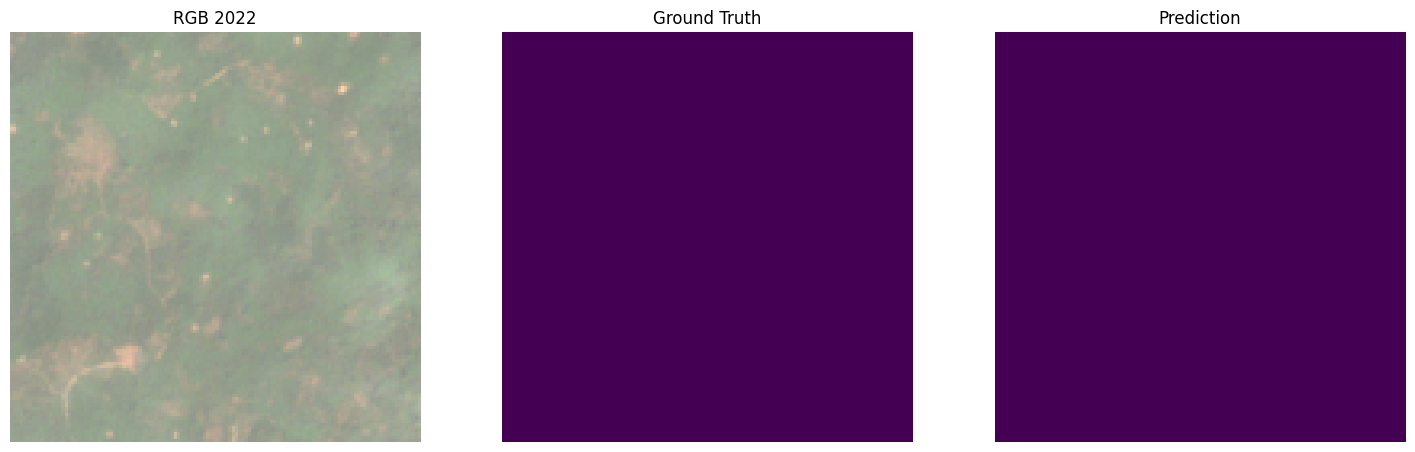


Showing batch 4


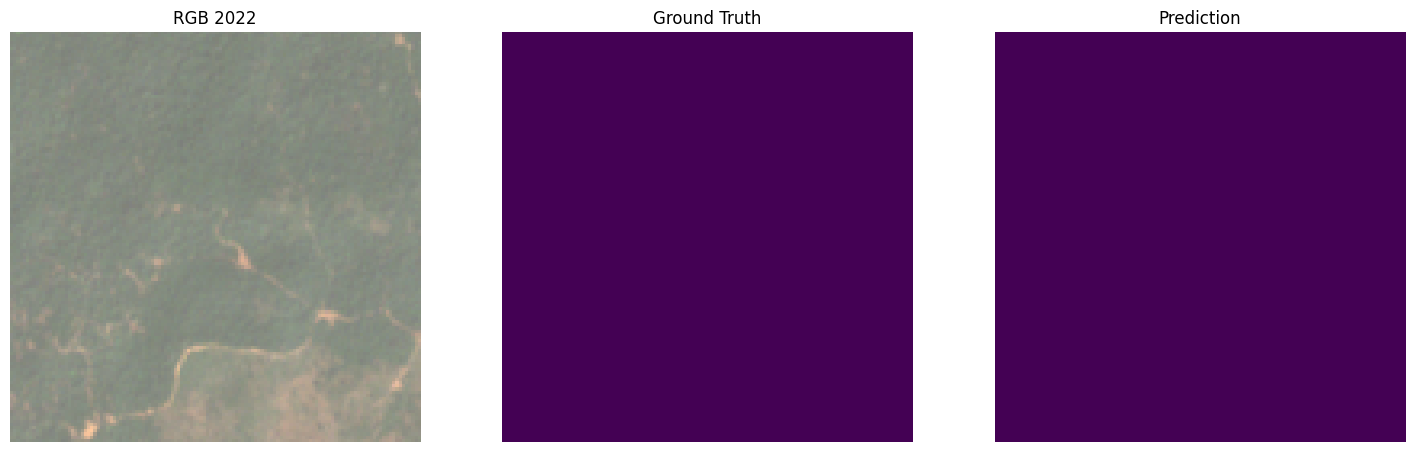

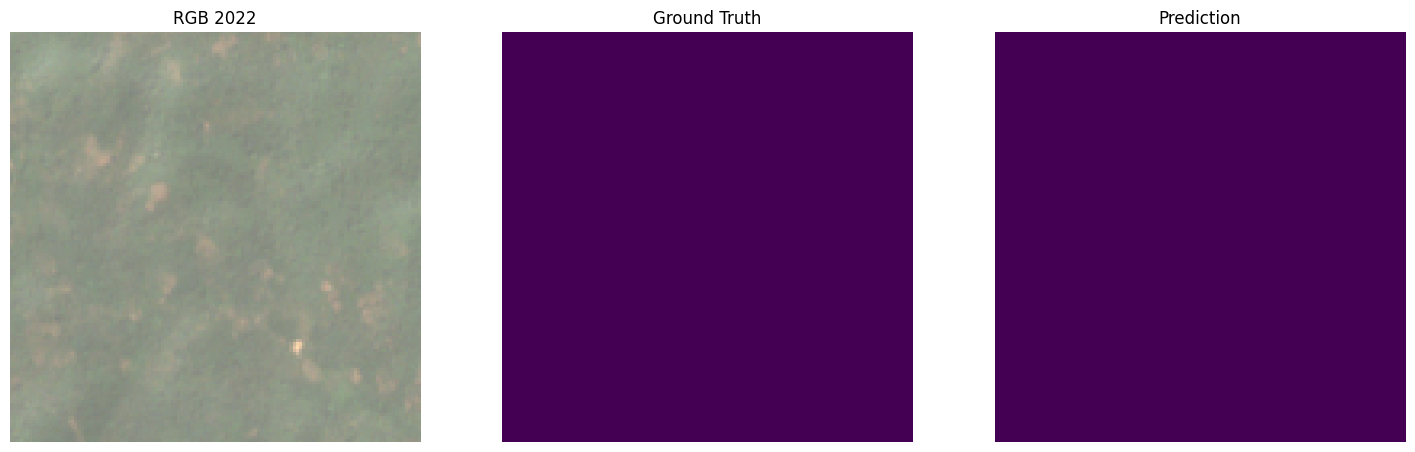

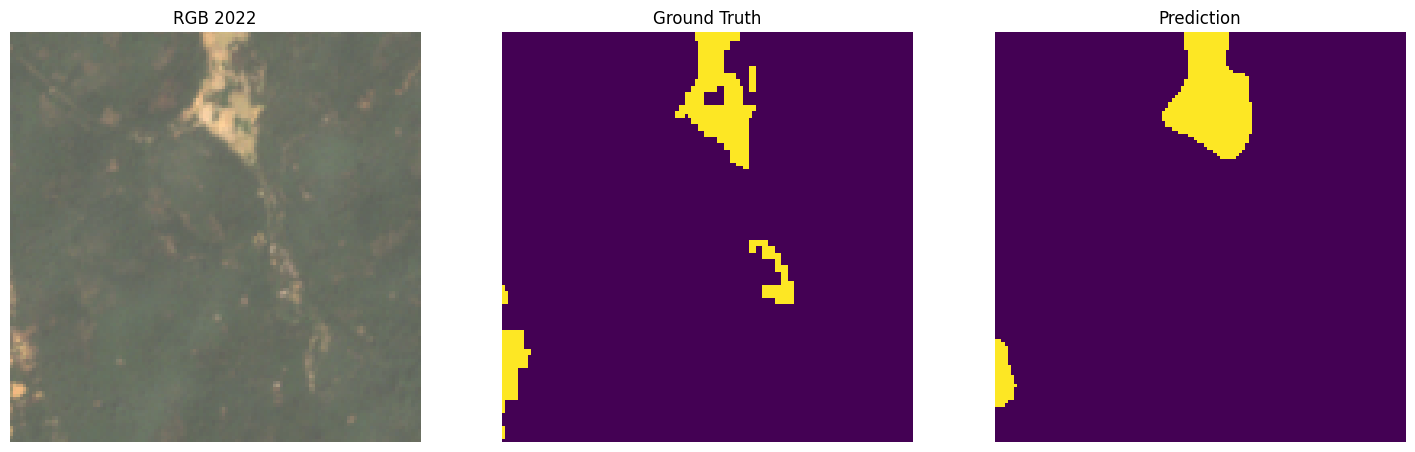

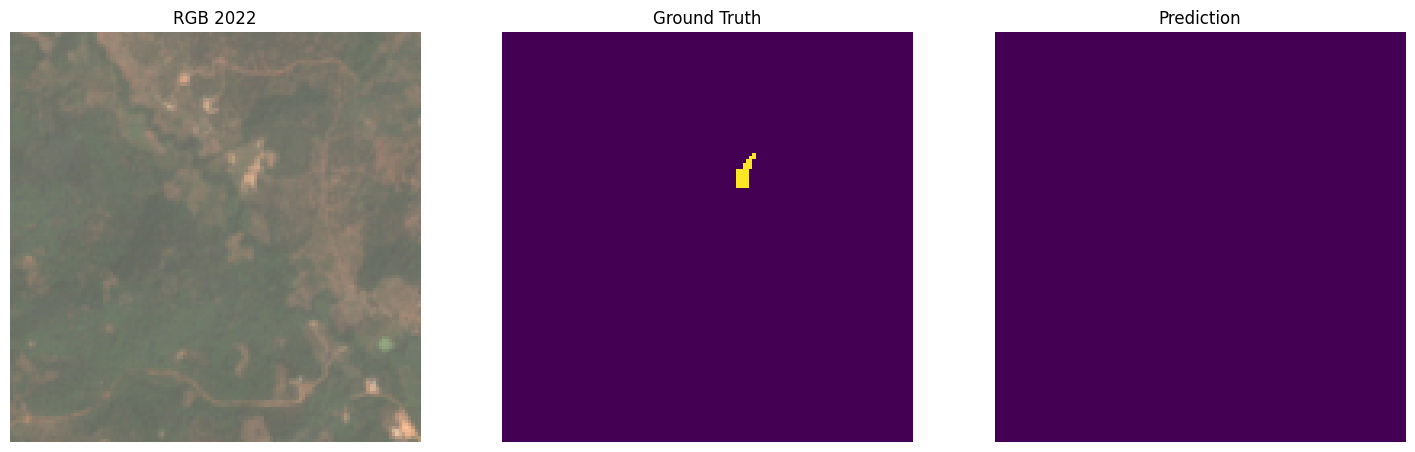

DONE


In [92]:
import matplotlib.pyplot as plt
import numpy as np

print("===================================")
print("MULTIPLE BATCH VISUALIZATION")
print("===================================")

data_module.setup("test")
data_loader = data_module.test_dataloader()

max_batches_to_show = 5

for batch_idx, batch in enumerate(data_loader):

    if batch_idx >= max_batches_to_show:
        break

    print(f"\nShowing batch {batch_idx}")

    pred_batch = preds[batch_idx][0][0]

    for i in range(min(len(batch["image"]), len(pred_batch))):

        image = batch["image"][i].cpu().numpy()
        mask = batch["mask"][i].cpu().numpy()

        pred = pred_batch[i].detach().cpu().numpy()

        if pred.ndim == 3:
            pred = np.argmax(pred, axis=0)

        red_2022 = image[2, 1]
        green_2022 = image[1, 1]
        blue_2022 = image[0, 1]

        rgb_2022 = np.stack(
            [red_2022, green_2022, blue_2022],
            axis=-1
        ).astype(np.float32)

        if rgb_2022.max() > 0:
            rgb_2022 = rgb_2022 / rgb_2022.max()

        plt.figure(figsize=(18, 6))

        plt.subplot(1, 3, 1)
        plt.imshow(rgb_2022)
        plt.title("RGB 2022")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(mask)
        plt.title("Ground Truth")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(pred)
        plt.title("Prediction")
        plt.axis("off")

        plt.show()

print("===================================")
print("DONE")
print("===================================")

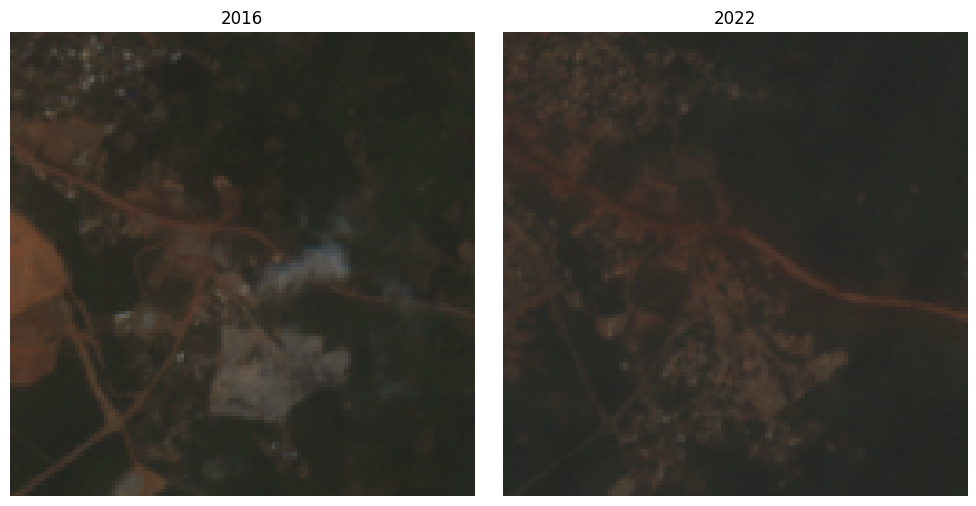

In [89]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

path_2016 = "SmallMinesDS/SmallMinesDS/2016/IMAGE/IMG_GH_0030_2016.tif"
path_2022 = "SmallMinesDS/SmallMinesDS/2022/IMAGE/IMG_GH_0030_2022.tif"

def plot_graph(path, title):
    with rasterio.open(path) as src:
        img = src.read()  # (C, H, W)

    # RGB (bandas 3,2,1) → índices [2,1,0]
    rgb = img[[2, 1, 0]].astype(np.float32)

    # normalización
    rgb = np.clip(rgb, 0, 10000) / 10000.0

    # (C,H,W) → (H,W,C)
    rgb = rgb.transpose(1, 2, 0)

    plt.imshow(rgb)
    plt.title(title)
    plt.axis("off")

# 🔥 plot lado a lado
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plot_graph(path_2016, "2016")

plt.subplot(1,2,2)
plot_graph(path_2022, "2022")

plt.tight_layout()
plt.show()

In [90]:
import rasterio
import numpy as np


def inspect_mask_classes(mask_path):
    with rasterio.open(mask_path) as src:
        mask = src.read(1)  # leer solo la primera banda

    unique_values, counts = np.unique(mask, return_counts=True)

    print(f"\nArchivo: {mask_path}")
    print(f"Shape: {mask.shape}")
    print(f"Tipo de dato: {mask.dtype}")
    print(f"Valores únicos: {unique_values}")

    print("\nDistribución de clases:")
    total_pixels = mask.size

    for value, count in zip(unique_values, counts):
        percentage = (count / total_pixels) * 100
        print(
            f"Clase {value}: "
            f"{count} píxeles "
            f"({percentage:.4f}%)"
        )


# verificar 2016
path_2016 = "SmallMinesDS/SmallMinesDS/2016/MASK/MASK_GH_0150_2016.tif"
inspect_mask_classes(path_2016)

# verificar 2022
path_2022 = "SmallMinesDS/SmallMinesDS/2022/MASK/MASK_GH_0150_2022.tif"
inspect_mask_classes(path_2022)


Archivo: SmallMinesDS/SmallMinesDS/2016/MASK/MASK_GH_0150_2016.tif
Shape: (128, 128)
Tipo de dato: uint8
Valores únicos: [0 1]

Distribución de clases:
Clase 0: 15218 píxeles (92.8833%)
Clase 1: 1166 píxeles (7.1167%)

Archivo: SmallMinesDS/SmallMinesDS/2022/MASK/MASK_GH_0150_2022.tif
Shape: (128, 128)
Tipo de dato: uint8
Valores únicos: [0 1]

Distribución de clases:
Clase 0: 12828 píxeles (78.2959%)
Clase 1: 3556 píxeles (21.7041%)
